
# SDG 12 Global E-Waste Analysis & Machine Learning Project

## Objective
This project focuses on:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Training
- Model Evaluation
- Prediction System
- Visualization

Dataset:
**SDG12_Global_EWaste_UN_Regions_Unclean_2020_2024.xlsx**


In [ ]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [6]:

# LOAD DATASET

df = pd.read_csv("SDG12_Global_EWaste_UN_Regions_Unclean_2020_2024.csv")

print(df.head())


                         UN_Region  Year   Population  E_Waste_kg_per_capita  \
0                     Eastern Asia  2024   39522366.0                  21.96   
1               South-Eastern Asia  2023   10951456.0                  22.41   
2  Latin America and the Caribbean  2023  159620848.0                  15.78   
3               Sub-Saharan Africa  2021  121181579.0                  14.06   
4                    Southern Asia  2020   21553486.0                  15.92   

   Total_E_Waste_metric_tons  Recycling_Rate_percent  \
0                  867911.16                   39.28   
1                  245422.13                   40.09   
2                 2518816.98                   64.22   
3                 1703813.00                   44.49   
4                  343131.50                   59.66   

   Formal_Collection_Rate_percent  Informal_Processing_percent  \
0                           28.07                        71.92   
1                            5.21                 

## Dataset Information

In [7]:

print(df.info())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   UN_Region                       5100 non-null   object 
 1   Year                            5100 non-null   int64  
 2   Population                      5050 non-null   float64
 3   E_Waste_kg_per_capita           5100 non-null   float64
 4   Total_E_Waste_metric_tons       5100 non-null   float64
 5   Recycling_Rate_percent          4846 non-null   float64
 6   Formal_Collection_Rate_percent  5100 non-null   float64
 7   Informal_Processing_percent     5100 non-null   float64
 8   Hazardous_Content_percent       5100 non-null   float64
 9   Landfill_Rate_percent           5100 non-null   float64
 10  Export_Rate_percent             5100 non-null   float64
 11  E_Waste_Policy_Index            5100 non-null   float64
 12  GDP_per_capita_USD              48

## Data Cleaning

In [8]:

# REMOVE EXTRA SPACES

df['UN_Region'] = df['UN_Region'].str.strip()

# CONVERT DATA TYPES

df['GDP_per_capita_USD'] = pd.to_numeric(
    df['GDP_per_capita_USD'],
    errors='coerce'
)

# HANDLE MISSING VALUES

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# REMOVE DUPLICATES

print("Duplicate Rows Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())


Duplicate Rows Before: 93
Duplicate Rows After: 0


## Remove Invalid Values

In [9]:

# REMOVE NEGATIVE VALUES

cols_no_negative = [
    'Population',
    'E_Waste_kg_per_capita',
    'Total_E_Waste_metric_tons',
    'GDP_per_capita_USD'
]

for col in cols_no_negative:
    df = df[df[col] >= 0]

# FIX INVALID PERCENTAGES

percentage_cols = [
    'Recycling_Rate_percent',
    'Formal_Collection_Rate_percent',
    'Informal_Processing_percent',
    'Hazardous_Content_percent',
    'Landfill_Rate_percent',
    'Export_Rate_percent',
    'Urbanization_Rate_percent'
]

for col in percentage_cols:
    df = df[(df[col] >= 0) & (df[col] <= 100)]

print("Dataset Shape After Cleaning:", df.shape)


Dataset Shape After Cleaning: (4807, 14)


## Feature Engineering

In [10]:

# FEATURE ENGINEERING

df['E_Waste_Per_Capita'] = (
    df['Total_E_Waste_metric_tons'] / df['Population']
)

df['Recycling_Efficiency'] = (
    df['Recycling_Rate_percent'] *
    df['Formal_Collection_Rate_percent']
)

print(df[['E_Waste_Per_Capita', 'Recycling_Efficiency']].head())


   E_Waste_Per_Capita  Recycling_Efficiency
0             0.02196             1102.5896
1             0.02241              208.8689
2             0.01578             1599.0780
3             0.01406              919.6083
4             0.01592             3277.7204


## Outlier Removal

In [11]:

important_cols = [
    'Total_E_Waste_metric_tons',
    'Population',
    'GDP_per_capita_USD'
]

for col in important_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Dataset Shape After Outlier Removal:", df.shape)


Dataset Shape After Outlier Removal: (4770, 16)


## Encoding Categorical Variables

In [12]:

df = pd.get_dummies(
    df,
    columns=['UN_Region'],
    drop_first=True
)

print(df.head())


   Year   Population  E_Waste_kg_per_capita  Total_E_Waste_metric_tons  \
0  2024   39522366.0                  21.96                  867911.16   
1  2023   10951456.0                  22.41                  245422.13   
2  2023  159620848.0                  15.78                 2518816.98   
3  2021  121181579.0                  14.06                 1703813.00   
4  2020   21553486.0                  15.92                  343131.50   

   Recycling_Rate_percent  Formal_Collection_Rate_percent  \
0                   39.28                           28.07   
1                   40.09                            5.21   
2                   64.22                           24.90   
3                   44.49                           20.67   
4                   59.66                           54.94   

   Informal_Processing_percent  Hazardous_Content_percent  \
0                        71.92                      24.73   
1                        39.80                      32.14   
2    

## Feature Scaling

In [13]:

scaler = StandardScaler()

scale_cols = [
    'Population',
    'E_Waste_kg_per_capita',
    'GDP_per_capita_USD',
    'E_Waste_Per_Capita',
    'Recycling_Efficiency'
]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(df.head())


   Year  Population  E_Waste_kg_per_capita  Total_E_Waste_metric_tons  \
0  2024   -1.202367               0.761832                  867911.16   
1  2023   -1.603083               0.818103                  245422.13   
2  2023    0.482052              -0.010955                 2518816.98   
3  2021   -0.057071              -0.226035                 1703813.00   
4  2020   -1.454387               0.006551                  343131.50   

   Recycling_Rate_percent  Formal_Collection_Rate_percent  \
0                   39.28                           28.07   
1                   40.09                            5.21   
2                   64.22                           24.90   
3                   44.49                           20.67   
4                   59.66                           54.94   

   Informal_Processing_percent  Hazardous_Content_percent  \
0                        71.92                      24.73   
1                        39.80                      32.14   
2          

## Exploratory Data Analysis (EDA)

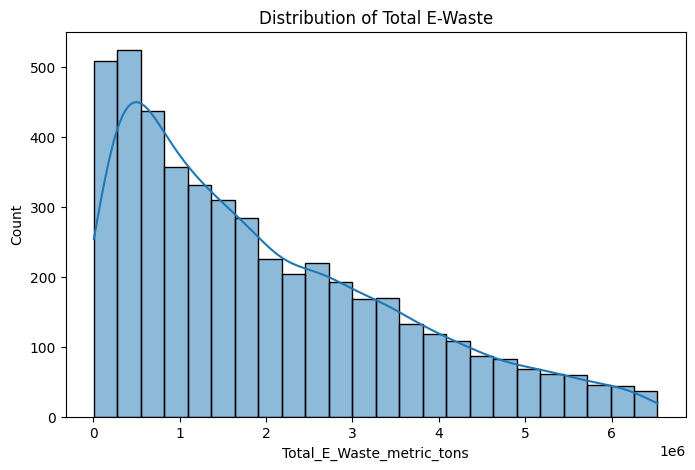

In [14]:

# DISTRIBUTION PLOT

plt.figure(figsize=(8,5))

sns.histplot(df['Total_E_Waste_metric_tons'], kde=True)

plt.title("Distribution of Total E-Waste")

plt.show()


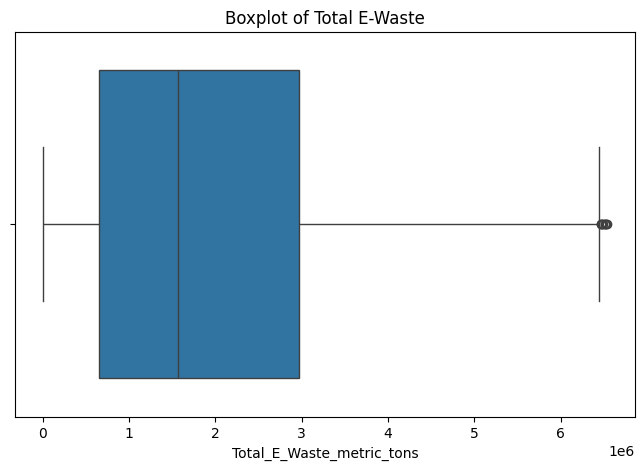

In [15]:

# BOXPLOT

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Total_E_Waste_metric_tons'])

plt.title("Boxplot of Total E-Waste")

plt.show()


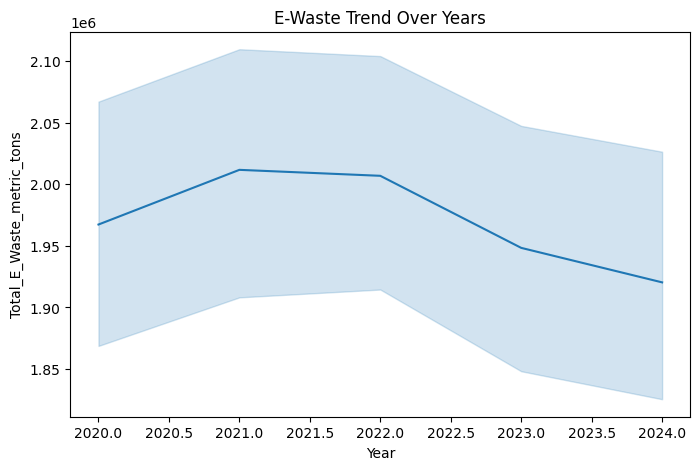

In [16]:

# TREND ANALYSIS

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='Year',
    y='Total_E_Waste_metric_tons'
)

plt.title("E-Waste Trend Over Years")

plt.show()


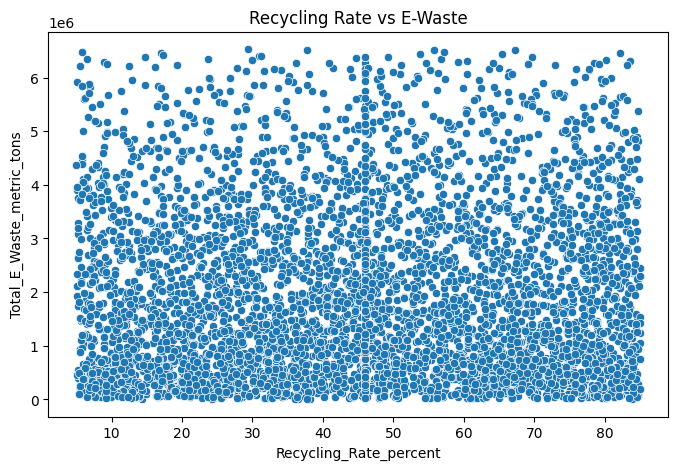

In [17]:

# SCATTER PLOT

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Recycling_Rate_percent',
    y='Total_E_Waste_metric_tons'
)

plt.title("Recycling Rate vs E-Waste")

plt.show()


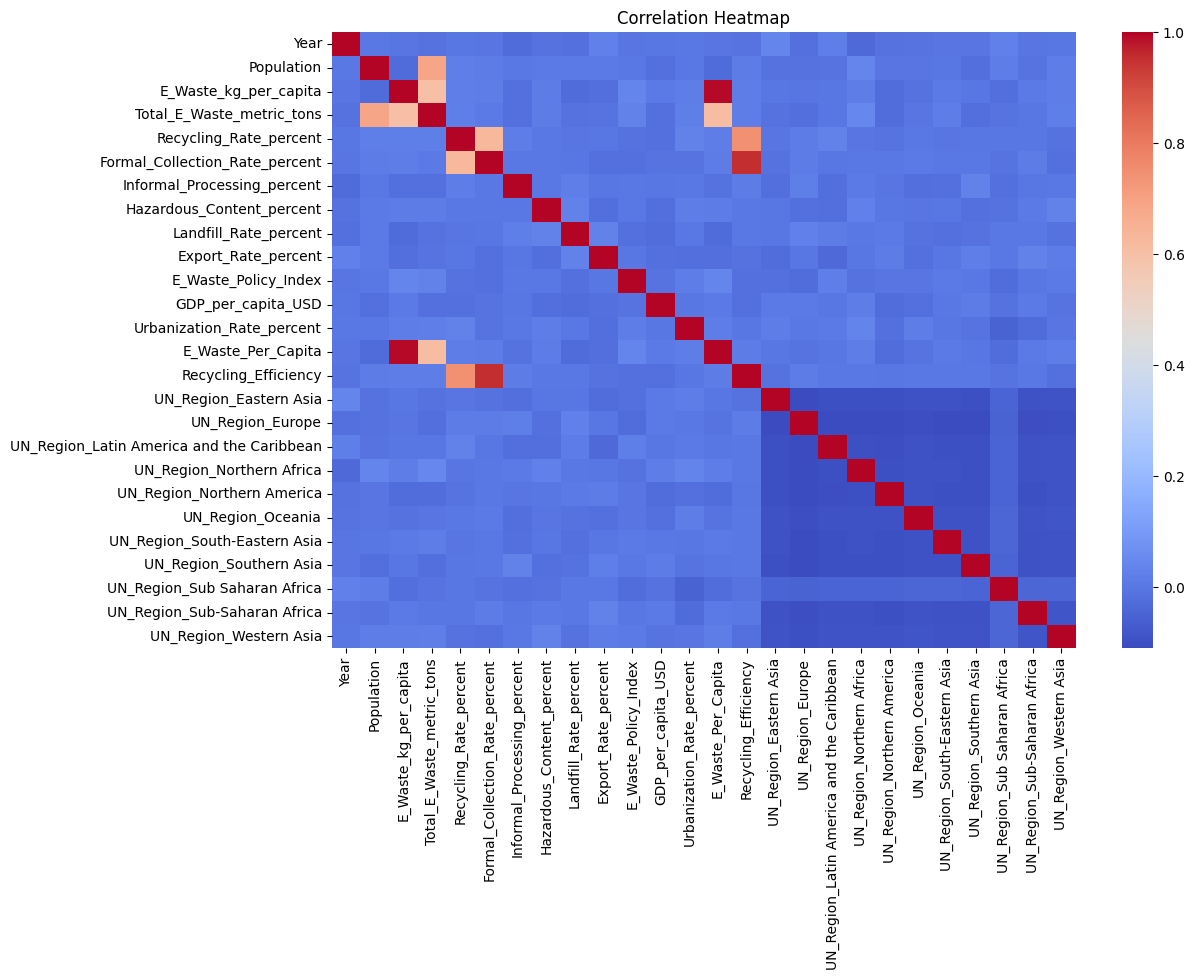

In [18]:

# CORRELATION HEATMAP

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


## Machine Learning Pipeline

In [19]:

# DEFINE FEATURES AND TARGET

X = df.drop('Total_E_Waste_metric_tons', axis=1)

y = df['Total_E_Waste_metric_tons']

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (3816, 25)
Testing Shape: (954, 25)


## Linear Regression Model

In [20]:

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, lr_predictions))

print("MSE:", mean_squared_error(y_test, lr_predictions))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))

print("R2 Score:", r2_score(y_test, lr_predictions))


Linear Regression Results
MAE: 430418.54585170915
MSE: 323110056775.0464
RMSE: 568427.7058474951
R2 Score: 0.8722479283004444


## Decision Tree Model

In [21]:

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, dt_predictions))

print("MSE:", mean_squared_error(y_test, dt_predictions))

print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))

print("R2 Score:", r2_score(y_test, dt_predictions))


Decision Tree Results
MAE: 61994.94553710324
MSE: 8082678088.258771
RMSE: 89903.71565324078
R2 Score: 0.9968042502887041


## Random Forest Model (Best Model)

In [22]:

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=15
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, rf_predictions))

print("MSE:", mean_squared_error(y_test, rf_predictions))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))

print("R2 Score:", r2_score(y_test, rf_predictions))


Random Forest Results
MAE: 25605.88565529505
MSE: 1531046005.5008926
RMSE: 39128.58297333156
R2 Score: 0.9993946511568773


## Model Comparison

In [23]:

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

r2_scores = [
    r2_score(y_test, lr_predictions),
    r2_score(y_test, dt_predictions),
    r2_score(y_test, rf_predictions)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores
})

print(comparison_df)


               Model  R2 Score
0  Linear Regression  0.872248
1      Decision Tree  0.996804
2      Random Forest  0.999395


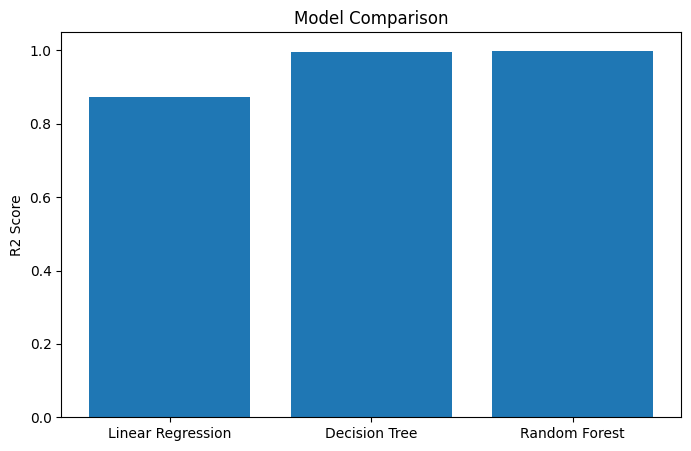

In [24]:

# VISUALIZE MODEL PERFORMANCE

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()


## Prediction Visualization

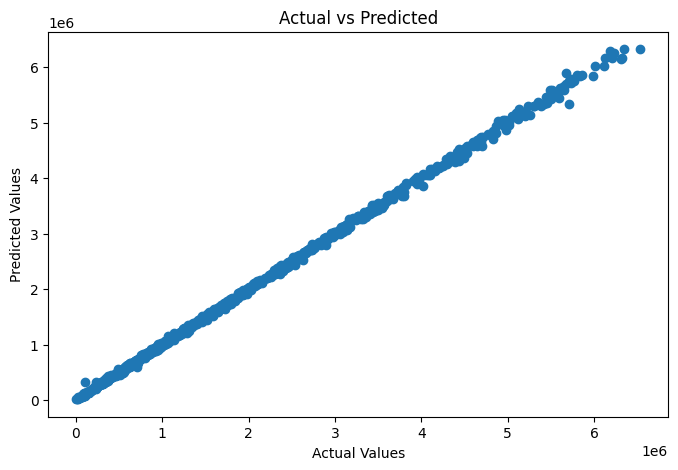

In [25]:

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()


## Feature Importance

In [26]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))


                        Feature  Importance
1                    Population    0.511691
12           E_Waste_Per_Capita    0.415701
2         E_Waste_kg_per_capita    0.071361
5   Informal_Processing_percent    0.000122
10           GDP_per_capita_USD    0.000122
9          E_Waste_Policy_Index    0.000120
11    Urbanization_Rate_percent    0.000119
8           Export_Rate_percent    0.000115
6     Hazardous_Content_percent    0.000114
7         Landfill_Rate_percent    0.000111


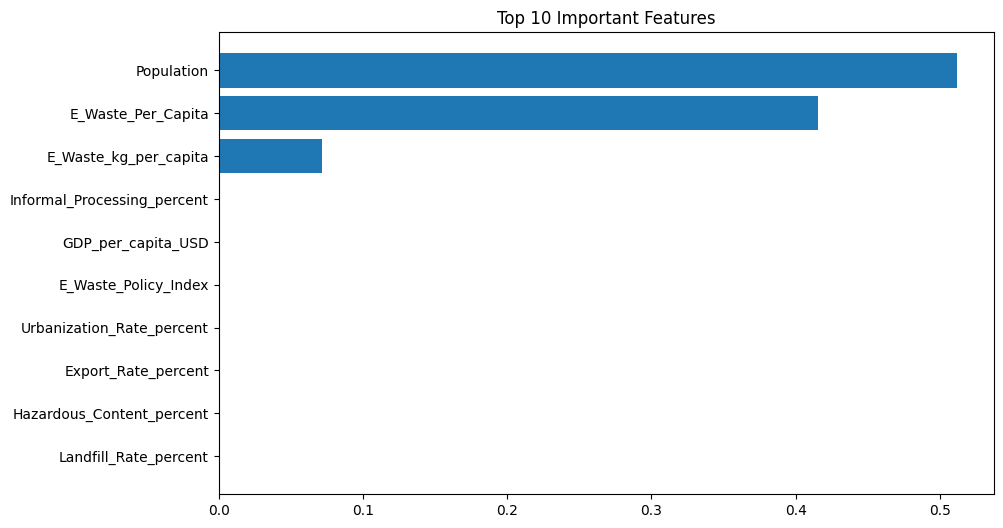

In [27]:

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()


## Prediction System

In [28]:

# SAMPLE PREDICTION

sample_data = X_test.iloc[0:1]

prediction = rf_model.predict(sample_data)

print("Predicted E-Waste:", prediction[0])

print("Actual E-Waste:", y_test.iloc[0])


Predicted E-Waste: 1697646.856169232
Actual E-Waste: 1740056.01



# Conclusion

## Summary
This project successfully:
- Cleaned and preprocessed the dataset
- Handled missing values and outliers
- Performed feature engineering
- Visualized trends and correlations
- Trained multiple ML models
- Evaluated model performance
- Built a prediction system

## Best Model
Random Forest performed best because it handles:
- Non-linear relationships
- Complex feature interactions
- Large datasets

## Future Improvements
- Use XGBoost for higher accuracy
- Add more years of data
- Deploy model as a web application
- Use real-time global e-waste datasets


In [ ]:
import joblib
joblib.dump(best_model, 'model.pkl')

NameError: name 'joblib' is not defined